In [ ]:
# Importing Important Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# Image → Tensor also automatically 0-255 -> 0-1
transform = transforms.Compose([
    transforms.ToTensor(),
])


train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    transform=transform
)

In [ ]:
batch_size = 64
# batch_size = images per iteration, shuffle for randomize dataset
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class SparseAutoencoder(nn.Module):

    def __init__(self, input_dim=3072, hidden_dim=1024):
        super(SparseAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            # here we need sigmoid because previously we normalize image in range of 0-1
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)

        decoded = self.decoder(encoded)

        return encoded, decoded

In [ ]:
# encoded is output of the encoder layer. and that show how each neuron will be activated ex :- [0.5 ,0.1 ,0.05 ,.....]
# rho = target sparsity ( here, we want only 5% neurons to get activated )

def sparsity_loss(encoded, rho=0.05):
    # rho_hat is average activation of each neuron across the batch.
    rho_hat = torch.mean(encoded, dim=0)
    # compare with actual sparsity and target sparsity and calculate Squared error.
    loss = torch.sum((rho_hat - rho)**2)
    return loss

so for example we have 3 image batch output from encoded layer

- Image1 → [0.1, 0.9, 0.2]
- Image2 → [0.2, 0.8, 0.3]
- Image3 → [0.0, 0.7, 0.4]

by size we can see there are 3 neuron
so each average will be
- Neuron1 → (0.1+0.2+0)/3 = 0.1
- Neuron2 → (0.9+0.8+0.7)/3 = 0.8
- Neuron3 → (0.2+0.3+0.4)/3 = 0.3

and that is the rho_hat

In [ ]:
# model initialization, loss and optimizer
model = SparseAutoencoder().to(device)
criterion = nn.MSELoss() # <- its reconstruction loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
def train_model(lambda_sparse):

    model = SparseAutoencoder().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    epochs = 10

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            images = images.view(images.size(0), -1).to(device)

            encoded, outputs = model(images)

            recon_loss = criterion(outputs, images)
            sparse_loss = sparsity_loss(encoded)

            loss = recon_loss + lambda_sparse * sparse_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print("Epoch:", epoch, "Loss:", total_loss)

    return model

In [ ]:
model = train_model(1e-5)

Epoch: 0 Loss: 21.8825863879174
Epoch: 1 Loss: 13.452100031077862
Epoch: 2 Loss: 10.665244988165796
Epoch: 3 Loss: 9.294096872210503
Epoch: 4 Loss: 8.564277187921107
Epoch: 5 Loss: 8.192164699546993
Epoch: 6 Loss: 7.947696395218372
Epoch: 7 Loss: 7.81209718901664
Epoch: 8 Loss: 7.723806772381067
Epoch: 9 Loss: 7.631570292636752


In [ ]:
model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1)
        images = images.to(device) # <--- Added this line to move images to the device
        encoded, outputs = model(images)
        loss = criterion(outputs, images)
        test_loss += loss.item()

print("Test Loss:", test_loss)

Test Loss: 1.4500140100717545


In [ ]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1)
images_flat = images_flat.to(device) # Add this line to move images to the device
encoded, outputs = model(images_flat)
outputs = outputs.view(-1, 3, 32, 32)

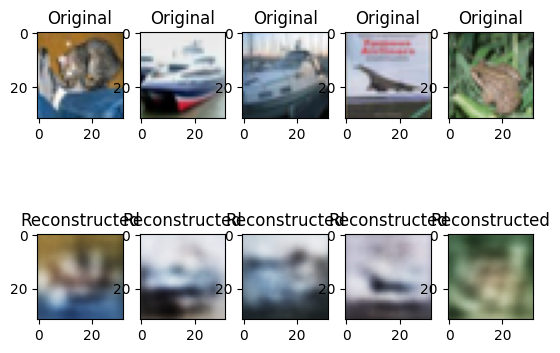

In [ ]:
for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.title("Original")

    plt.subplot(2,5,i+6)
    plt.imshow(outputs[i].detach().cpu().permute(1,2,0))
    plt.title("Reconstructed")

plt.show()

# Experiment with Diffrent learning rate

In [ ]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

In [ ]:
sparsity_values = [0, 1e-5, 1e-4, 1e-3]
results = []
for lam in sparsity_values:

    print("Training with lambda_sparse =", lam)
    model = train_model(lam)
    model.eval()
    with torch.no_grad():
        _, outputs = model(images_flat)

    results.append(outputs.view(-1,3,32,32).cpu())

Training with lambda_sparse = 0
Epoch: 0 Loss: 19.368091746233404
Epoch: 1 Loss: 10.948729803785682
Epoch: 2 Loss: 8.364058607257903
Epoch: 3 Loss: 7.1368573643267155
Epoch: 4 Loss: 6.681391571648419
Epoch: 5 Loss: 6.196529563050717
Epoch: 6 Loss: 5.951773560140282
Epoch: 7 Loss: 5.648639695253223
Epoch: 8 Loss: 5.572133490350097
Epoch: 9 Loss: 5.413515214342624
Training with lambda_sparse = 1e-05
Epoch: 0 Loss: 21.960599552839994
Epoch: 1 Loss: 13.523055571131408
Epoch: 2 Loss: 10.74294108338654
Epoch: 3 Loss: 9.523338154889643
Epoch: 4 Loss: 8.758427227847278
Epoch: 5 Loss: 8.396024636924267
Epoch: 6 Loss: 8.289416546933353
Epoch: 7 Loss: 8.160116931423545
Epoch: 8 Loss: 8.024921032600105
Epoch: 9 Loss: 7.968717665411532
Training with lambda_sparse = 0.0001
Epoch: 0 Loss: 28.782531848177314
Epoch: 1 Loss: 20.62433163076639
Epoch: 2 Loss: 17.487159810960293
Epoch: 3 Loss: 16.208078522235155
Epoch: 4 Loss: 15.775378397665918
Epoch: 5 Loss: 15.569472283124924
Epoch: 6 Loss: 15.400169014

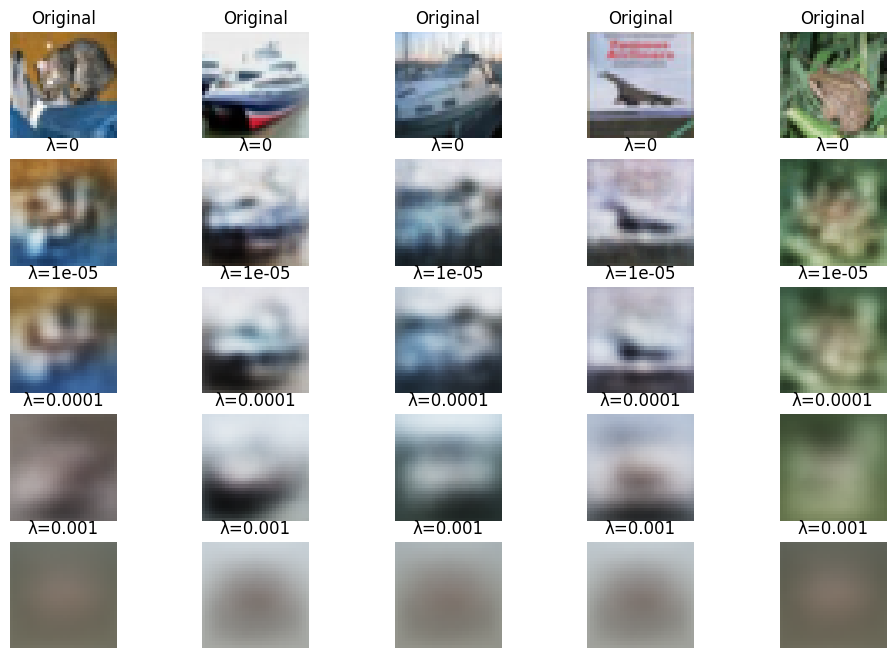

In [ ]:
num_images = 5
rows = len(sparsity_values) + 1

plt.figure(figsize=(12,8))

# Original images
for i in range(num_images):

    plt.subplot(rows, num_images, i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis("off")

# Reconstructed images
for r, recon in enumerate(results):

    for i in range(num_images):

        plt.subplot(rows, num_images, (r+1)*num_images + i + 1)
        plt.imshow(recon[i].permute(1,2,0))
        plt.title(f"λ={sparsity_values[r]}")
        plt.axis("off")

plt.show()

| Sparsity Strength | Reconstruction Quality      |
| ----------------- | --------------------------- |
| Low               | High reconstruction quality |
| Medium            | Moderate reconstruction     |
| High              | Poor reconstruction         |


Active neurons ↓

Information capacity ↓

**Sparse Autoencoder Functionality:** The model successfully learns to encode and decode images, demonstrating its ability to reconstruct the input data.

**Sparsity Loss:** The custom sparsity_loss function effectively measures how far the average activation of neurons deviates from a target sparsity (rho), encouraging a sparse representation in the hidden layer.

**Role of lambda_sparse:** This hyperparameter acts as a regularization strength, balancing the reconstruction accuracy (MSE loss) against the sparsity of the hidden layer representation (sparsity loss).

**Impact on Reconstruction Quality:**

* **lambda_sparse = 0:** When lambda_sparse is zero, no sparsity constraint is applied, and the autoencoder focuses solely on reconstruction, yielding the highest visual quality but potentially redundant hidden representations.
* **Low lambda_sparse (e.g., 1e-5):** Introduces a mild sparsity constraint, maintaining good reconstruction quality while starting to encourage more efficient representations.

* **High lambda_sparse (e.g., 1e-4, 1e-3):** Imposes a strong penalty for non-sparse activations. This leads to significantly blurrier and less accurate reconstructions, as the model prioritizes activating fewer neurons over precise image details. This trade-off is evident in the increased total loss with higher lambda_sparse values, indicating the model struggles more to satisfy both objectives simultaneously.